In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [24]:
import ast

In [5]:
import string
import re
import pymorphy3
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/3b703cd6-2481-4285-bdc3-
[nltk_data]     8bea7b95bc92/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

In [7]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

# 1. Загрузка данных

In [3]:
df = pd.read_csv('comment.csv', index_col = 0)
df.head()

,post_id,comments_text
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже..."
1,12103.0,За Бориса Борисовича Надеждина!!!
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!


In [10]:
df.shape

(4754, 2)

# 2. Очистка данных

In [9]:
def tokenize_text(raw_text: str):
    words = raw_text.split()
    re_punc = re.compile('[%s]'%re.escape(string.punctuation))
    stripped = [re_punc.sub('', w) for w in words]
    words_lower = [word.lower() for word in stripped]
    words_alpha = [word for word in words_lower if word.isalpha()]
    words_stop = [word for word in words_alpha if not word in stop_words]
    words_morph = [morph.parse(word)[0].normal_form for word in words_stop]
    tokens = [word for word in words_morph if len(word)>3]
    
    return tokens

In [11]:
tokenized = df['comments_text'].apply(tokenize_text)
df = df.assign(tokenized = tokenized)
df.head()

,post_id,comments_text,tokenized
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","[этот, игра, демократия, результат, итак, изве..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"[борис, борисович, надеждин]"
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","[вообще, голосовать, ярослав, ниловый]"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","[интересно, выборы, пройти, честно, расклад, д..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"[выборы, выбор, вообще]"


In [12]:
df.to_csv ('comments_tokenized.csv')

In [13]:
words_list = list (df['tokenized'])

In [14]:
 all_words = np.concatenate (words_list)

In [16]:
all_words_freq = FreqDist(all_words)
print(f'Наиболее популярные слова: {all_words_freq.most_common(100)}')
print (f'\nОбщее количество уникальных слов: ', len(all_words_freq.keys()))

Наиболее популярные слова: [('путин', 1070), ('россия', 864), ('свой', 774), ('человек', 685), ('который', 603), ('грудинин', 602), ('страна', 591), ('народ', 545), ('президент', 484), ('деньга', 418), ('весь', 392), ('выборы', 385), ('такой', 369), ('власть', 322), ('быть', 310), ('один', 300), ('жить', 290), ('государство', 279), ('знать', 273), ('русский', 272), ('говорить', 261), ('кандидат', 260), ('время', 258), ('сделать', 252), ('просто', 249), ('голосовать', 245), ('хотеть', 232), ('делать', 230), ('навальный', 227), ('каждый', 219), ('другой', 218), ('мочь', 214), ('новый', 210), ('должный', 204), ('стать', 200), ('какой', 190), ('вообще', 178), ('война', 176), ('иметь', 174), ('сказать', 169), ('очень', 168), ('почему', 166), ('работать', 165), ('против', 164), ('этот', 159), ('гражданин', 155), ('идти', 154), ('никто', 154), ('дать', 154), ('нужно', 154), ('день', 153), ('работа', 153), ('друг', 152), ('система', 149), ('нужный', 146), ('российский', 143), ('жизнь', 143), (

/tmp/ipykernel_874/1397073842.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


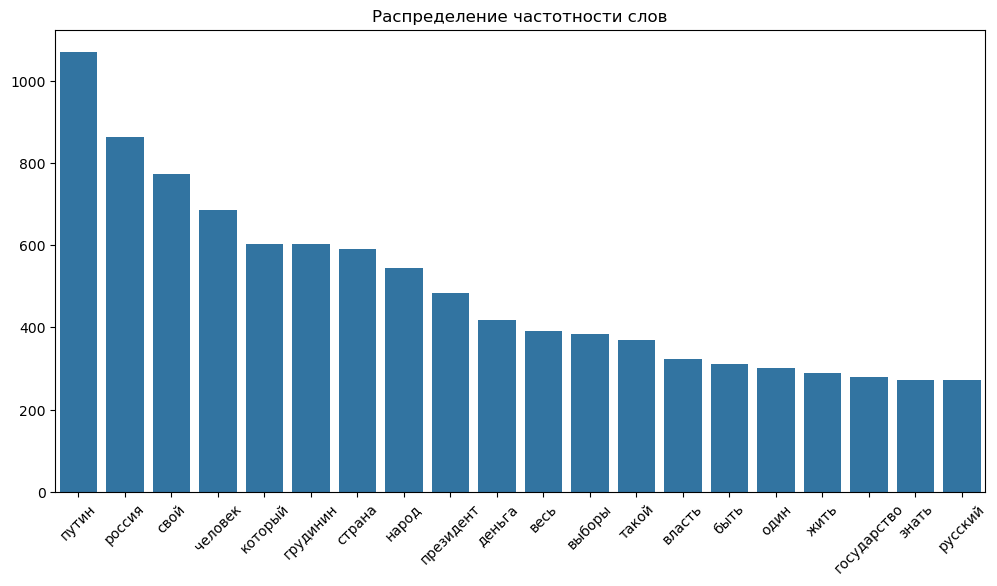

In [17]:
count, words = [],[]
for word in all_words_freq_posts.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [18]:
df = pd.read_csv('comments_tokenized.csv', index_col = 0)
df.head()

,post_id,comments_text,tokenized
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","['этот', 'игра', 'демократия', 'результат', 'и..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"['борис', 'борисович', 'надеждин']"
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","['вообще', 'голосовать', 'ярослав', 'ниловый']"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","['интересно', 'выборы', 'пройти', 'честно', 'р..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"['выборы', 'выбор', 'вообще']"


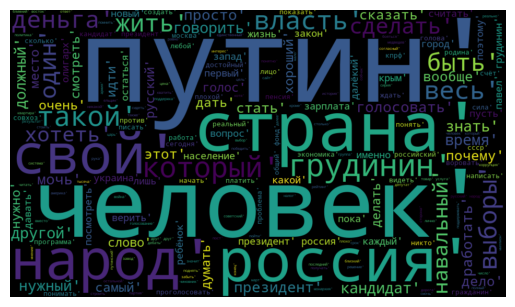

In [19]:
textt = ','.join(word for word in df['tokenized'])
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# 3. Выявление и удаление дополнительных стоп-слов

In [20]:
stop_words_ex = ['который','такой','какой','каждый']

In [21]:
def full_stop_words (text):
    words = [word for word in text if not word in stop_words_ex]
    return words

In [23]:
pure_tokens = df['tokenized'].apply(full_stop_words)
df = df.assign(pure_tokens=pure_tokens)
df.head()

,post_id,comments_text,tokenized,pure_tokens
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","['этот', 'игра', 'демократия', 'результат', 'и...","[[, ', э, т, о, т, ', ,, , ', и, г, р, а, ', ..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"['борис', 'борисович', 'надеждин']","[[, ', б, о, р, и, с, ', ,, , ', б, о, р, и, ..."
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","['вообще', 'голосовать', 'ярослав', 'ниловый']","[[, ', в, о, о, б, щ, е, ', ,, , ', г, о, л, ..."
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","['интересно', 'выборы', 'пройти', 'честно', 'р...","[[, ', и, н, т, е, р, е, с, н, о, ', ,, , ', ..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"['выборы', 'выбор', 'вообще']","[[, ', в, ы, б, о, р, ы, ', ,, , ', в, ы, б, ..."


In [25]:
word_list = list(df['tokenized'])

In [30]:
s = word_list[:1]
s

["['этот', 'игра', 'демократия', 'результат', 'итак', 'известный', 'лучнуть', 'деньга', 'выделить', 'выборы', 'отдать', 'пенсионер', 'поддержание']"]

In [27]:
len (words_list)

4754

In [38]:
comments_list = []
for i in range (len(words_list)):
    comments_list.append(words_list[i])

In [41]:
tokens = []
for i in range(len(words_list)):
    tokens.append(full_stop_words(words_list[i]))

In [43]:
df['tokens'] = tokens
df.head()

,post_id,comments_text,tokenized,pure_tokens,tokens
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","['этот', 'игра', 'демократия', 'результат', 'и...","[[, ', э, т, о, т, ', ,, , ', и, г, р, а, ', ...","[этот, игра, демократия, результат, итак, изве..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"['борис', 'борисович', 'надеждин']","[[, ', б, о, р, и, с, ', ,, , ', б, о, р, и, ...","[борис, борисович, надеждин]"
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","['вообще', 'голосовать', 'ярослав', 'ниловый']","[[, ', в, о, о, б, щ, е, ', ,, , ', г, о, л, ...","[вообще, голосовать, ярослав, ниловый]"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","['интересно', 'выборы', 'пройти', 'честно', 'р...","[[, ', и, н, т, е, р, е, с, н, о, ', ,, , ', ...","[интересно, выборы, пройти, честно, расклад, д..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"['выборы', 'выбор', 'вообще']","[[, ', в, ы, б, о, р, ы, ', ,, , ', в, ы, б, ...","[выборы, выбор, вообще]"


# 4. Окончательный разведочный анализ данных

In [48]:
words_list = list (df['tokens'])

In [49]:
 all_words = np.concatenate (words_list)

In [50]:
all_words_freq = FreqDist(all_words)
print(f'Наиболее популярные слова: {all_words_freq.most_common(100)}')
print (f'\nОбщее количество уникальных слов: ', len(all_words_freq.keys()))

Наиболее популярные слова: [('путин', 1070), ('россия', 864), ('свой', 774), ('человек', 685), ('грудинин', 602), ('страна', 591), ('народ', 545), ('президент', 484), ('деньга', 418), ('весь', 392), ('выборы', 385), ('власть', 322), ('быть', 310), ('один', 300), ('жить', 290), ('государство', 279), ('знать', 273), ('русский', 272), ('говорить', 261), ('кандидат', 260), ('время', 258), ('сделать', 252), ('просто', 249), ('голосовать', 245), ('хотеть', 232), ('делать', 230), ('навальный', 227), ('другой', 218), ('мочь', 214), ('новый', 210), ('должный', 204), ('стать', 200), ('вообще', 178), ('война', 176), ('иметь', 174), ('сказать', 169), ('очень', 168), ('почему', 166), ('работать', 165), ('против', 164), ('этот', 159), ('гражданин', 155), ('идти', 154), ('никто', 154), ('дать', 154), ('нужно', 154), ('день', 153), ('работа', 153), ('друг', 152), ('система', 149), ('нужный', 146), ('российский', 143), ('жизнь', 143), ('дело', 141), ('видеть', 140), ('самый', 138), ('зарплата', 137), (

/tmp/ipykernel_874/2021039292.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


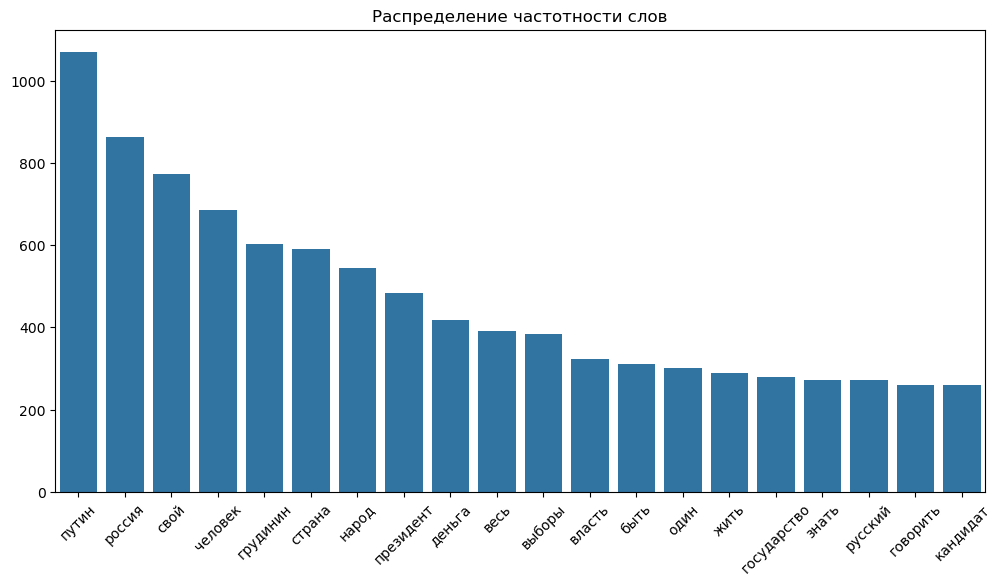

In [51]:
count, words = [],[]
for word in all_words_freq.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [52]:
df.to_csv ('comments_pure.csv')

In [53]:
df = pd.read_csv('comments_pure.csv', index_col = 0)
df.head()

,post_id,comments_text,tokenized,pure_tokens,tokens
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","['этот', 'игра', 'демократия', 'результат', 'и...","['[', ""'"", 'э', 'т', 'о', 'т', ""'"", ',', ' ', ...","['этот', 'игра', 'демократия', 'результат', 'и..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"['борис', 'борисович', 'надеждин']","['[', ""'"", 'б', 'о', 'р', 'и', 'с', ""'"", ',', ...","['борис', 'борисович', 'надеждин']"
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","['вообще', 'голосовать', 'ярослав', 'ниловый']","['[', ""'"", 'в', 'о', 'о', 'б', 'щ', 'е', ""'"", ...","['вообще', 'голосовать', 'ярослав', 'ниловый']"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","['интересно', 'выборы', 'пройти', 'честно', 'р...","['[', ""'"", 'и', 'н', 'т', 'е', 'р', 'е', 'с', ...","['интересно', 'выборы', 'пройти', 'честно', 'р..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"['выборы', 'выбор', 'вообще']","['[', ""'"", 'в', 'ы', 'б', 'о', 'р', 'ы', ""'"", ...","['выборы', 'выбор', 'вообще']"


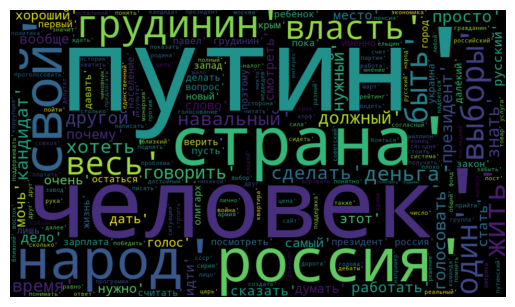

In [54]:
textt = ','.join(word for word in df['tokens'])
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# 5. Векторизация

In [55]:
tfidf_vect = TfidfVectorizer (max_df = 1.0, min_df = 2, stop_words = None)
doc_term_matrix = tfidf_vect.fit_transform(df['tokens'])

# 6. Тематическое моделирование

In [59]:
LDA = LatentDirichletAllocation (n_components=3, random_state = 42)
LDA.fit(doc_term_matrix)

,n_components,3
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [60]:
for i, topic in enumerate (LDA.components_):
    print (f'Top 10 words for topic No {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print ('\n')

Top 10 words for topic No 0: 
['владимир', 'жить', 'поднять', 'работать', 'путин', 'пенсия', 'народ', 'партия', 'человек', 'россия']


Top 10 words for topic No 1: 
['почему', 'человек', 'страна', 'кандидат', 'россия', 'президент', 'выборы', 'путин', 'голосовать', 'грудинин']


Top 10 words for topic No 2: 
['деньга', 'президент', 'россия', 'быть', 'человек', 'народ', 'страна', 'свой', 'навальный', 'путин']




In [63]:
nmf = NMF(n_components = 3, random_state = 42)
nmf.fit(doc_term_matrix)

,n_components,3
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [64]:
for i, topic in enumerate (nmf.components_):
    print (f'Top 10 words for topic No {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print ('\n')

Top 10 words for topic No 0: 
['свой', 'человек', 'народ', 'победить', 'страна', 'выборы', 'россия', 'президент', 'голосовать', 'путин']


Top 10 words for topic No 1: 
['человек', 'хороший', 'страна', 'кандидат', 'выборы', 'народ', 'президент', 'павел', 'голосовать', 'грудинин']


Top 10 words for topic No 2: 
['говорить', 'стать', 'народ', 'свой', 'страна', 'человек', 'выборы', 'россия', 'президент', 'навальный']




In [65]:
topic_values = nmf.transform(doc_term_matrix)
topic_values.shape

(4754, 3)

In [66]:
df['Topic_NMF'] = topic_values.argmax(axis = 1)
df.head()

,post_id,comments_text,tokenized,pure_tokens,tokens,Topic_NMF
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","['этот', 'игра', 'демократия', 'результат', 'и...","['[', ""'"", 'э', 'т', 'о', 'т', ""'"", ',', ' ', ...","['этот', 'игра', 'демократия', 'результат', 'и...",2
1,12103.0,За Бориса Борисовича Надеждина!!!,"['борис', 'борисович', 'надеждин']","['[', ""'"", 'б', 'о', 'р', 'и', 'с', ""'"", ',', ...","['борис', 'борисович', 'надеждин']",0
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","['вообще', 'голосовать', 'ярослав', 'ниловый']","['[', ""'"", 'в', 'о', 'о', 'б', 'щ', 'е', ""'"", ...","['вообще', 'голосовать', 'ярослав', 'ниловый']",0
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","['интересно', 'выборы', 'пройти', 'честно', 'р...","['[', ""'"", 'и', 'н', 'т', 'е', 'р', 'е', 'с', ...","['интересно', 'выборы', 'пройти', 'честно', 'р...",2
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"['выборы', 'выбор', 'вообще']","['[', ""'"", 'в', 'ы', 'б', 'о', 'р', 'ы', ""'"", ...","['выборы', 'выбор', 'вообще']",2


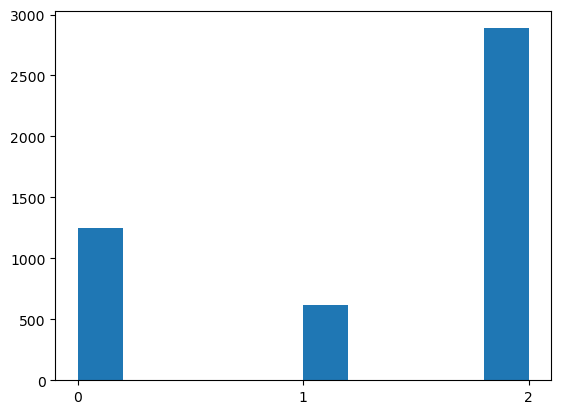

In [67]:
plt.hist(df['Topic_NMF'])
plt.xticks ([0,1,2]);

In [68]:
topic_1 = df[df['Topic_NMF']==0]
topic_1.shape

(1251, 6)

In [69]:
topic_2 = df[df['Topic_NMF']==1]
topic_2.shape

(616, 6)

In [70]:
topic_3 = df[df['Topic_NMF']==2]
topic_3.shape

(2887, 6)

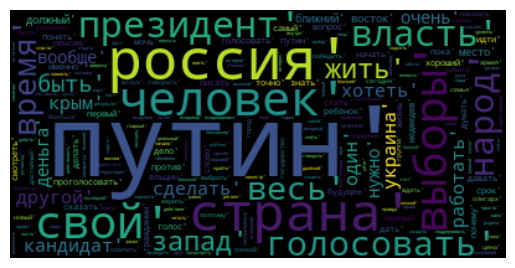

In [71]:
textt = ''.join(w for w in topic_1.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

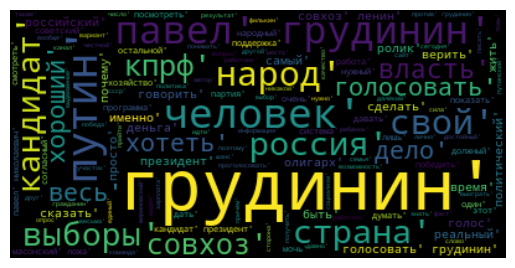

In [72]:
textt = ''.join(w for w in topic_2.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

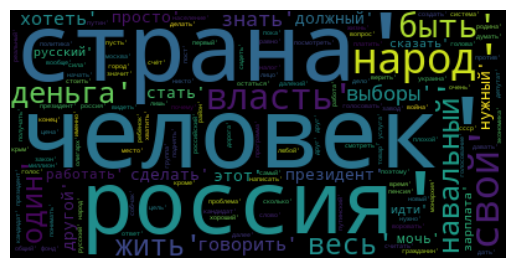

In [73]:
textt = ''.join(w for w in topic_3.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()